# Verifying the Concentration of Distances in High Dimensions

Following Figure 8.13c, we examine how the Euclidean distance of samples from a standard normal at dimensions 25, 100, and 500 becomes concentrated as dimensionality grows.

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [5]:
rng = np.random.default_rng(42)
dimensions = [25, 100, 500]
samples_per_dim = 10000

# Sample points and compute Euclidean distances from the origin
squared_distances = {}
distances = {}
for d in dimensions:
    samples = rng.standard_normal(size=(samples_per_dim, d))
    squared = np.sum(samples ** 2, axis=1)
    squared_distances[d] = squared
    distances[d] = np.sqrt(squared)

# Quick numerical summary
for d, dist in distances.items():
    mean = np.mean(dist)
    std = np.std(dist)
    print(f"Dimension {d:>3d}: mean distance = {mean:.3f}, std = {std:.3f}")

Dimension  25: mean distance = 4.957, std = 0.700
Dimension 100: mean distance = 9.972, std = 0.705
Dimension 500: mean distance = 22.345, std = 0.709


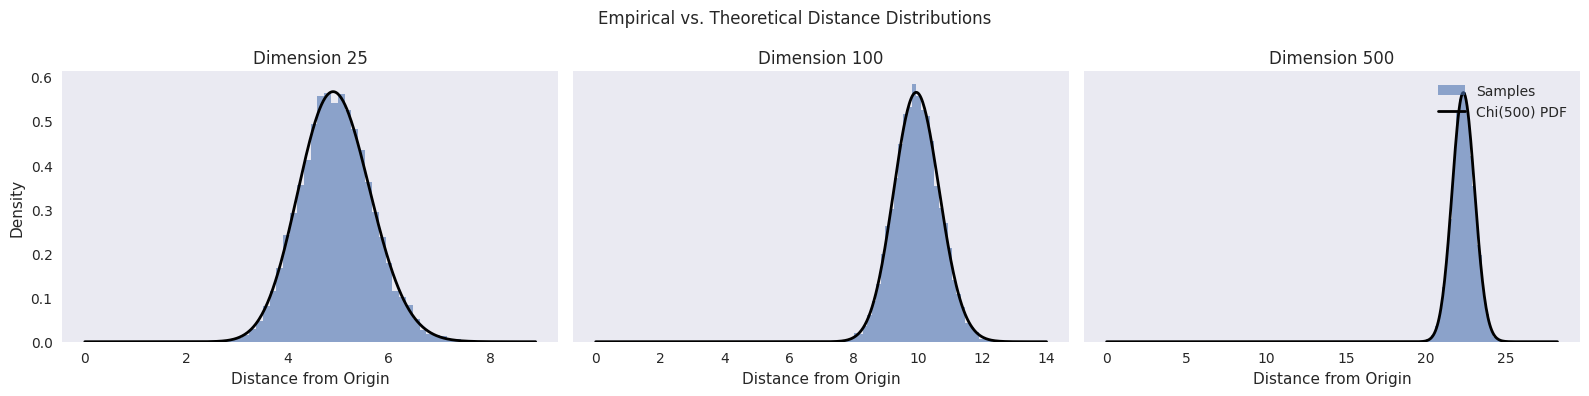

In [6]:
def chi_pdf(r, k):
    r = np.asarray(r)
    pdf = np.zeros_like(r, dtype=float)
    positive = r > 0
    log_coeff = -((k / 2 - 1) * np.log(2) + math.lgamma(k / 2))
    pdf[positive] = np.exp(log_coeff + (k - 1) * np.log(r[positive]) - r[positive] ** 2 / 2)
    if k == 1:
        pdf[np.logical_not(positive)] = np.inf
    else:
        pdf[np.logical_not(positive)] = 0.0
    return pdf

fig, axes = plt.subplots(1, len(dimensions), figsize=(16, 4), sharey=True)
for ax, d in zip(axes, dimensions):
    dist = distances[d]
    ax.hist(dist, bins=40, density=True, alpha=0.6, label="Samples")

    r_grid = np.linspace(0, dist.max() * 1.1, 500)
    ax.plot(r_grid, chi_pdf(r_grid, d), color="black", lw=2, label=f"Chi({d}) PDF")

    ax.set_title(f"Dimension {d}")
    ax.set_xlabel("Distance from Origin")
    ax.grid(False)

axes[0].set_ylabel("Density")
axes[-1].legend(loc="upper right")
fig.suptitle("Empirical vs. Theoretical Distance Distributions")
plt.tight_layout()
plt.show()

The observed distances follow a chi distribution with $k$ degrees of freedom (often written $\chi_k$). For samples $x \sim \mathcal{N}(0, I_k)$, the Euclidean norm $\|x\|$ has density

$$f(r; k) = \frac{1}{2^{k/2 - 1}\,\Gamma(k/2)} r^{k-1} e^{-r^2/2}, \qquad r \ge 0,$$

which matches the theoretical curves overlaid on the histograms.